# MCB Evaluation & Analysis Notebook
**Sections:** RQ1 (reliability) → RQ2 (disagreement analysis) → RQ3 (corpus patterns)  
Run cells in order. All outputs save to `../outputs/figures/`

In [1]:
# ── CELL 1: IMPORTS & SETUP ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score,
    confusion_matrix, classification_report
)
from pathlib import Path

# Output directory
FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(exist_ok=True)

# Category orders — used consistently across all plots
TONE_LABELS  = ['T1','T2','T3','T4','T5']
THEME_LABELS = ['TH1','TH2','TH3','TH4','TH5','TH6']

TONE_NAMES = {
    'T1': 'T1 Calm/Meditative',
    'T2': 'T2 Ecstatic/Improvisatory',
    'T3': 'T3 Anxious/Restless',
    'T4': 'T4 Comic/Absurdist',
    'T5': 'T5 Despairing/Dark'
}
THEME_NAMES = {
    'TH1': 'TH1 Spirituality',
    'TH2': 'TH2 Jazz/Music',
    'TH3': 'TH3 Autobiography',
    'TH4': 'TH4 Mexico/Place',
    'TH5': 'TH5 Mortality/Body',
    'TH6': 'TH6 Meta-Poetry'
}

# Colour palettes
TONE_COLORS  = {'T1':'#4393c3','T2':'#74c476','T3':'#fd8d3c','T4':'#9e9ac8','T5':'#d73027'}
THEME_COLORS = {'TH1':'#4393c3','TH2':'#74c476','TH3':'#fd8d3c',
                'TH4':'#9e9ac8','TH5':'#d73027','TH6':'#8c6d31'}

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

print('Setup complete.')

Setup complete.


In [2]:
# ── CELL 2: LOAD DATA & BUILD BOTH DATASETS ───────────────────────────

# ── Dataset A: Full 244-chorus model output ───────────────────────────
df = pd.read_csv(
    '../outputs/annotations_labels_only.csv',
    dtype={'chorus_id': str}
)

# Numeric sort key — handles 216-A, 216-B, 216-C
def chorus_to_float(cid):
    cid = str(cid).strip()
    if cid.endswith('-A'): return float(cid.replace('-A','')) + 0.1
    if cid.endswith('-B'): return float(cid.replace('-B','')) + 0.2
    if cid.endswith('-C'): return float(cid.replace('-C','')) + 0.3
    try: return float(cid)
    except: return np.nan

df['chorus_num'] = df['chorus_id'].apply(chorus_to_float)
df = df.sort_values('chorus_num').reset_index(drop=True)

print('=== DATASET A: Full Corpus ===')
print(f'Total choruses:         {len(df)}')
print(f'Successfully annotated: {(df["annotation_success"]==True).sum()}')
print(f'Failed:                 {(df["annotation_success"]!=True).sum()}')
print()
print('Tone distribution:')
print(df['model_tone'].value_counts().reindex(TONE_LABELS))
print()
print('Theme distribution:')
print(df['model_theme'].value_counts().reindex(THEME_LABELS))

# ── Dataset B: Gold standard — 22 human annotations ──────────────────
# tone_flag and theme_flag are SEPARATE (split ambiguity)
# Format: chorus_id: (human_tone, human_theme, tone_flag, theme_flag)
HUMAN = {
    '25':    ('T1', 'TH1', 0, 0),
    '141':   ('T1', 'TH1', 0, 0),
    '75':    ('T2', 'TH6', 0, 1),
    '223':   ('T2', 'TH6', 0, 1),
    '89':    ('T3', 'TH3', 0, 0),
    '104':   ('T3', 'TH3', 2, 0),
    '24':    ('T4', 'TH1', 0, 0),
    '31':    ('T4', 'TH6', 0, 1),
    '103':   ('T5', 'TH3', 0, 1),
    '240':   ('T5', 'TH2', 2, 0),
    '105':   ('T1', 'TH1', 0, 0),
    '216-B': ('T1', 'TH1', 0, 1),
    '37':    ('T2', 'TH2', 0, 1),
    '239':   ('T1', 'TH2', 0, 2),
    '87':    ('T3', 'TH3', 0, 1),
    '55':    ('T3', 'TH3', 1, 0),
    '9':     ('T2', 'TH4', 0, 0),
    '207':   ('T1', 'TH4', 0, 2),
    '40':    ('T4', 'TH5', 0, 2),
    '162':   ('T5', 'TH5', 0, 1),
    '11':    ('T1', 'TH6', 1, 0),
    '216-A': ('T4', 'TH6', 2, 0),
}

gold = pd.DataFrame([
    {'chorus_id': cid, 'human_tone': v[0], 'human_theme': v[1],
     'tone_flag': v[2], 'theme_flag': v[3]}
    for cid, v in HUMAN.items()
])
gold = gold.merge(
    df[['chorus_id','model_tone','model_theme']],
    on='chorus_id', how='left'
)

print()
print('=== DATASET B: Gold Standard ===')
print(gold[['chorus_id','human_tone','model_tone',
           'human_theme','model_theme','tone_flag','theme_flag']].to_string(index=False))

=== DATASET A: Full Corpus ===
Total choruses:         244
Successfully annotated: 244
Failed:                 0

Tone distribution:
model_tone
T1     72
T2    100
T3     31
T4      5
T5     36
Name: count, dtype: int64

Theme distribution:
model_theme
TH1    90
TH2    96
TH3    21
TH4    24
TH5     9
TH6     4
Name: count, dtype: int64

=== DATASET B: Gold Standard ===
chorus_id human_tone model_tone human_theme model_theme  tone_flag  theme_flag
       25         T1         T1         TH1         TH1          0           0
      141         T1         T1         TH1         TH1          0           0
       75         T2         T2         TH6         TH2          0           1
      223         T2         T2         TH6         TH2          0           1
       89         T3         T5         TH3         TH3          0           0
      104         T3         T3         TH3         TH3          2           0
       24         T4         T5         TH1         TH1          0        

In [3]:
# ── CELL 3: RQ1 — CORE RELIABILITY METRICS ───────────────────────────
# Overall accuracy + Cohen's Kappa + per-class F1
# Numbers that go directly into Section 5, RQ1 paragraph.

g = gold.dropna(subset=['model_tone','model_theme'])
n = len(g)

# ── Accuracy & Kappa ──────────────────────────────────────────────────
tone_acc   = accuracy_score(g['human_tone'],  g['model_tone'])
theme_acc  = accuracy_score(g['human_theme'], g['model_theme'])
tone_kappa = cohen_kappa_score(g['human_tone'],  g['model_tone'])
theme_kappa= cohen_kappa_score(g['human_theme'], g['model_theme'])

# Kappa interpretation
def kappa_label(k):
    if k < 0.20: return 'Slight'
    if k < 0.40: return 'Fair'
    if k < 0.60: return 'Moderate'
    if k < 0.80: return 'Substantial'
    return 'Almost perfect'

print('=' * 50)
print('RQ1: RELIABILITY METRICS (n=22)')
print('=' * 50)
print(f'  Tone  accuracy: {tone_acc:.3f}  ({tone_acc*100:.1f}%)')
print(f'  Theme accuracy: {theme_acc:.3f}  ({theme_acc*100:.1f}%)')
print()
print(f'  Tone  Kappa: {tone_kappa:.3f}  → {kappa_label(tone_kappa)}')
print(f'  Theme Kappa: {theme_kappa:.3f}  → {kappa_label(theme_kappa)}')
print()

# ── Per-class F1 ──────────────────────────────────────────────────────
print('Tone per-class F1:')
tone_report = classification_report(
    g['human_tone'], g['model_tone'],
    labels=TONE_LABELS, zero_division=0, output_dict=True
)
for lbl in TONE_LABELS:
    r = tone_report.get(lbl, {})
    print(f'  {lbl}: P={r.get("precision",0):.2f}  '
          f'R={r.get("recall",0):.2f}  '
          f'F1={r.get("f1-score",0):.2f}  '
          f'n={int(r.get("support",0))}')
print()
print('Theme per-class F1:')
theme_report = classification_report(
    g['human_theme'], g['model_theme'],
    labels=THEME_LABELS, zero_division=0, output_dict=True
)
for lbl in THEME_LABELS:
    r = theme_report.get(lbl, {})
    print(f'  {lbl}: P={r.get("precision",0):.2f}  '
          f'R={r.get("recall",0):.2f}  '
          f'F1={r.get("f1-score",0):.2f}  '
          f'n={int(r.get("support",0))}')

RQ1: RELIABILITY METRICS (n=22)
  Tone  accuracy: 0.409  (40.9%)
  Theme accuracy: 0.591  (59.1%)

  Tone  Kappa: 0.261  → Fair
  Theme Kappa: 0.506  → Moderate

Tone per-class F1:
  T1: P=0.75  R=0.43  F1=0.55  n=7
  T2: P=0.40  R=1.00  F1=0.57  n=4
  T3: P=0.50  R=0.50  F1=0.50  n=4
  T4: P=0.00  R=0.00  F1=0.00  n=4
  T5: P=0.00  R=0.00  F1=0.00  n=3

Theme per-class F1:
  TH1: P=0.71  R=1.00  F1=0.83  n=5
  TH2: P=0.33  R=1.00  F1=0.50  n=3
  TH3: P=1.00  R=0.60  F1=0.75  n=5
  TH4: P=1.00  R=1.00  F1=1.00  n=2
  TH5: P=0.00  R=0.00  F1=0.00  n=2
  TH6: P=0.00  R=0.00  F1=0.00  n=5


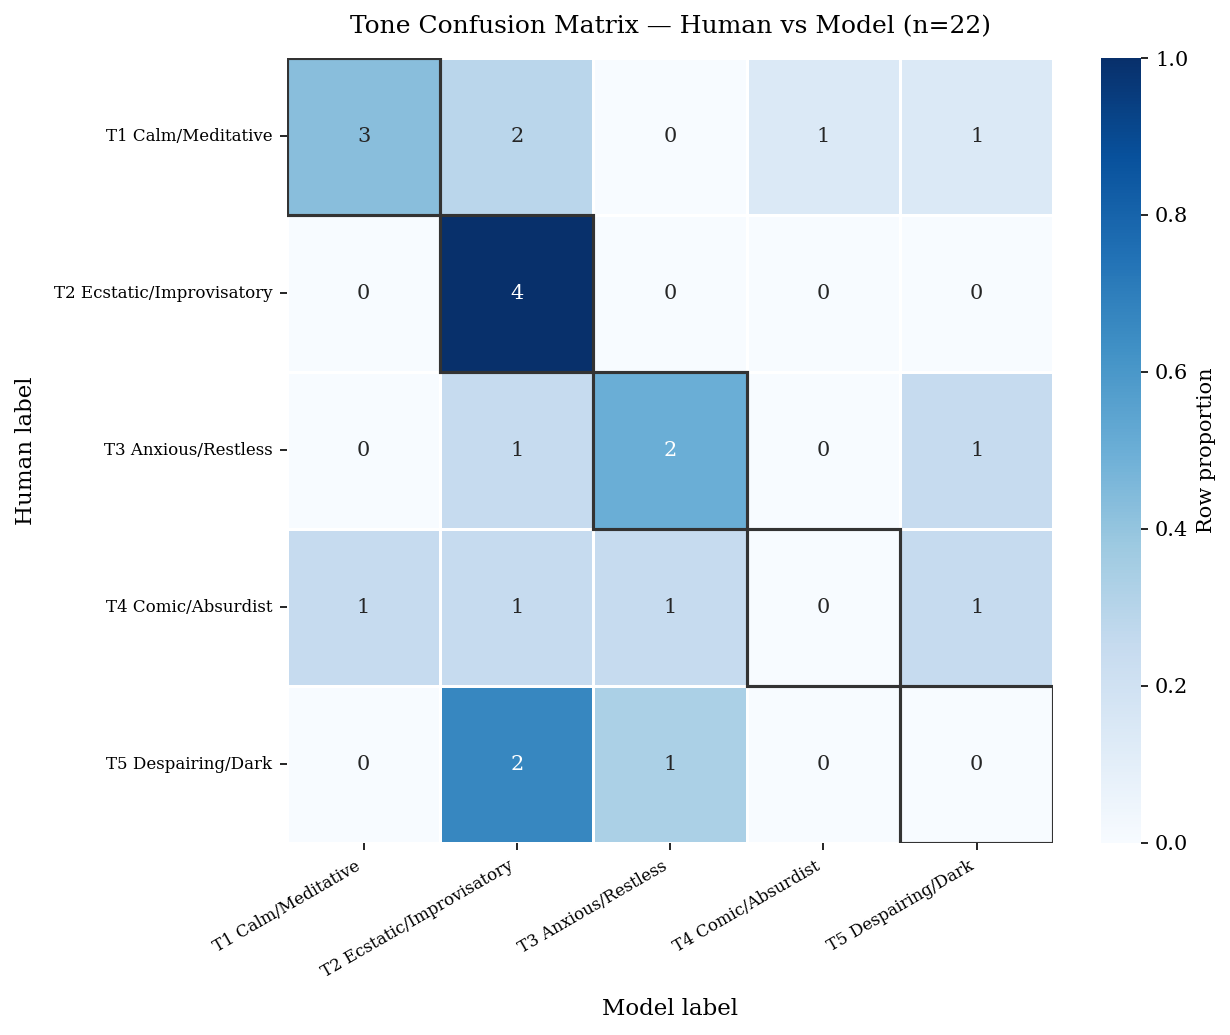

Saved: ../outputs/figures/confusion_tone.png


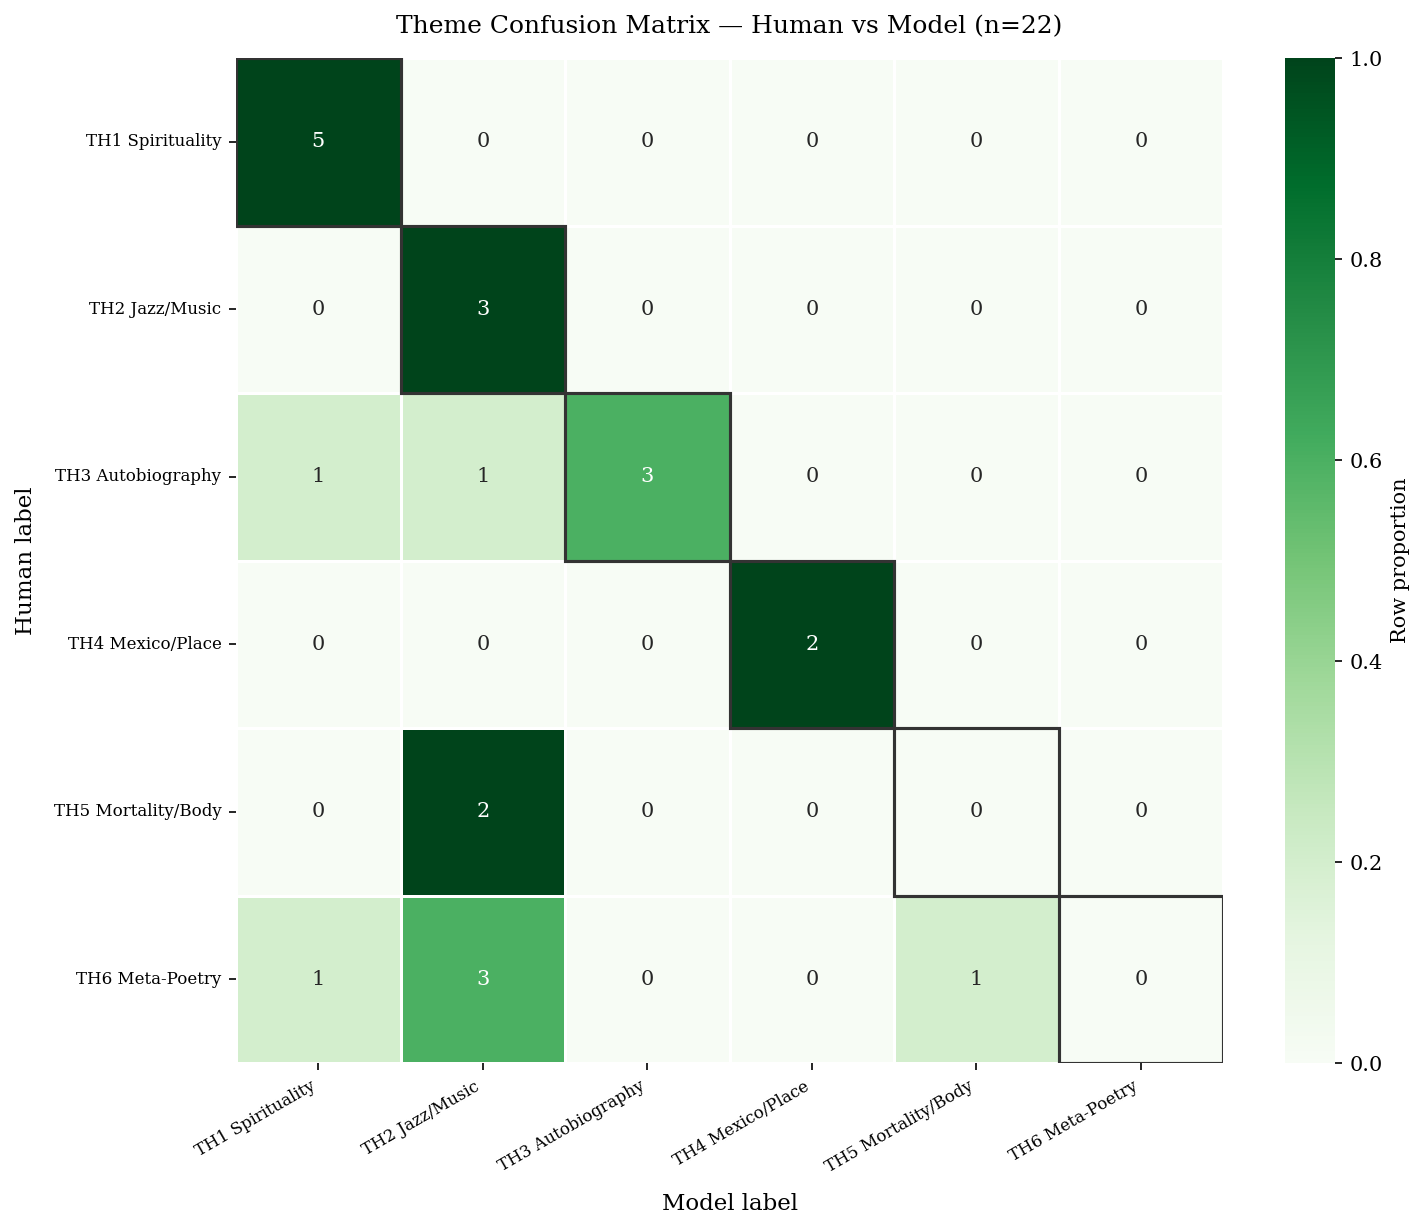

Saved: ../outputs/figures/confusion_theme.png

Tone confusion matrix (rows=human, cols=model):
    T1  T2  T3  T4  T5
T1   3   2   0   1   1
T2   0   4   0   0   0
T3   0   1   2   0   1
T4   1   1   1   0   1
T5   0   2   1   0   0

Theme confusion matrix (rows=human, cols=model):
     TH1  TH2  TH3  TH4  TH5  TH6
TH1    5    0    0    0    0    0
TH2    0    3    0    0    0    0
TH3    1    1    3    0    0    0
TH4    0    0    0    2    0    0
TH5    0    2    0    0    0    0
TH6    1    3    0    0    1    0


In [4]:
# ── CELL 4: CONFUSION MATRICES ────────────────────────────────────────
# Two heatmaps: tone (5×5) and theme (6×6).
# Rows = human label, Columns = model label.
# Cell colour = row proportion (so a perfect row is solid blue).
# Cell number = raw count.
# Disagreements above diagonal = model assigned 'higher' category.
# Disagreements below diagonal = model assigned 'lower' category.

def plot_confusion(y_true, y_pred, labels, label_names,
                   title, filename, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    # Normalise by row for colour
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm.astype(float)/row_sums, 0)

    n = len(labels)
    fig, ax = plt.subplots(figsize=(n*1.5+1, n*1.3+0.5))

    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        xticklabels=labels, yticklabels=labels,
        cmap=cmap, ax=ax, vmin=0, vmax=1,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Row proportion'}
    )

    # Highlight diagonal
    for i in range(n):
        ax.add_patch(plt.Rectangle((i, i), 1, 1,
                     fill=False, edgecolor='#333', lw=1.5))

    ax.set_xlabel('Model label', fontsize=11, labelpad=8)
    ax.set_ylabel('Human label', fontsize=11, labelpad=8)
    ax.set_title(title, fontsize=12, pad=12)
    ax.tick_params(axis='both', labelsize=10)

    # Add full names as secondary tick labels
    ax.set_xticklabels([label_names.get(l,l) for l in labels],
                       rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels([label_names.get(l,l) for l in labels],
                       rotation=0, fontsize=8)

    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')
    return cm

g = gold.dropna(subset=['model_tone','model_theme'])

cm_tone = plot_confusion(
    g['human_tone'], g['model_tone'],
    TONE_LABELS, TONE_NAMES,
    'Tone Confusion Matrix — Human vs Model (n=22)',
    'confusion_tone.png'
)

cm_theme = plot_confusion(
    g['human_theme'], g['model_theme'],
    THEME_LABELS, THEME_NAMES,
    'Theme Confusion Matrix — Human vs Model (n=22)',
    'confusion_theme.png',
    cmap='Greens'
)

# Print the raw matrices for reference
print()
print('Tone confusion matrix (rows=human, cols=model):')
print(pd.DataFrame(cm_tone, index=TONE_LABELS, columns=TONE_LABELS))
print()
print('Theme confusion matrix (rows=human, cols=model):')
print(pd.DataFrame(cm_theme, index=THEME_LABELS, columns=THEME_LABELS))

In [5]:
# ── CELL 5: RQ2 — DISAGREEMENT ANALYSIS ──────────────────────────────
# Prints every disagreement case with its chorus_id, both labels,
# and the ambiguity flags — so you can see exactly which disagreements
# are on flag-0 (unexpected) vs flag-1/2 (predicted by the scheme).

g = gold.dropna(subset=['model_tone','model_theme'])

tone_disagree  = g[g['human_tone']  != g['model_tone']]
theme_disagree = g[g['human_theme'] != g['model_theme']]

print('=== TONE DISAGREEMENTS ===')
print(f'{len(tone_disagree)}/22 choruses disagree on tone')
print()
for _, row in tone_disagree.iterrows():
    flag_note = ['clear', 'dual', 'undecidable'][int(row['tone_flag'])]
    print(f'  Chorus {row["chorus_id"]:6s}: '
          f'human={row["human_tone"]}  model={row["model_tone"]}  '
          f'tone_flag={row["tone_flag"]} ({flag_note})')

print()
print('=== THEME DISAGREEMENTS ===')
print(f'{len(theme_disagree)}/22 choruses disagree on theme')
print()
for _, row in theme_disagree.iterrows():
    flag_note = ['clear', 'dual', 'undecidable'][int(row['theme_flag'])]
    print(f'  Chorus {row["chorus_id"]:6s}: '
          f'human={row["human_theme"]}  model={row["model_theme"]}  '
          f'theme_flag={row["theme_flag"]} ({flag_note})')

print()
print('=== BOTH DISAGREE ===')
both = g[(g['human_tone'] != g['model_tone']) &
          (g['human_theme'] != g['model_theme'])]
print(f'{len(both)} choruses disagree on both tone AND theme:')
for _, row in both.iterrows():
    print(f'  Chorus {row["chorus_id"]}: '
          f'tone {row["human_tone"]}→{row["model_tone"]}  '
          f'theme {row["human_theme"]}→{row["model_theme"]}')

=== TONE DISAGREEMENTS ===
13/22 choruses disagree on tone

  Chorus 89    : human=T3  model=T5  tone_flag=0 (clear)
  Chorus 24    : human=T4  model=T5  tone_flag=0 (clear)
  Chorus 31    : human=T4  model=T1  tone_flag=0 (clear)
  Chorus 103   : human=T5  model=T3  tone_flag=0 (clear)
  Chorus 240   : human=T5  model=T2  tone_flag=2 (undecidable)
  Chorus 216-B : human=T1  model=T5  tone_flag=0 (clear)
  Chorus 239   : human=T1  model=T2  tone_flag=0 (clear)
  Chorus 87    : human=T3  model=T2  tone_flag=0 (clear)
  Chorus 207   : human=T1  model=T4  tone_flag=0 (clear)
  Chorus 40    : human=T4  model=T2  tone_flag=0 (clear)
  Chorus 162   : human=T5  model=T2  tone_flag=0 (clear)
  Chorus 11    : human=T1  model=T2  tone_flag=1 (dual)
  Chorus 216-A : human=T4  model=T3  tone_flag=2 (undecidable)

=== THEME DISAGREEMENTS ===
9/22 choruses disagree on theme

  Chorus 75    : human=TH6  model=TH2  theme_flag=1 (dual)
  Chorus 223   : human=TH6  model=TH2  theme_flag=1 (dual)
  Chorus

=== ACCURACY BY AMBIGUITY FLAG ===

TONE:
  Flag 0 (n=17): 7/17 correct (41%)  — choruses: ['25', '141', '75', '223', '89', '24', '31', '103', '105', '216-B', '37', '239', '87', '9', '207', '40', '162']
  Flag 1 (n=2): 1/2 correct (50%)  — choruses: ['55', '11']
  Flag 2 (n=3): 1/3 correct (33%)  — choruses: ['104', '240', '216-A']

THEME:
  Flag 0 (n=11): 8/11 correct (73%)  — choruses: ['25', '141', '89', '104', '24', '240', '105', '55', '9', '11', '216-A']
  Flag 1 (n=8): 3/8 correct (38%)  — choruses: ['75', '223', '31', '103', '216-B', '37', '87', '162']
  Flag 2 (n=3): 2/3 correct (67%)  — choruses: ['239', '207', '40']



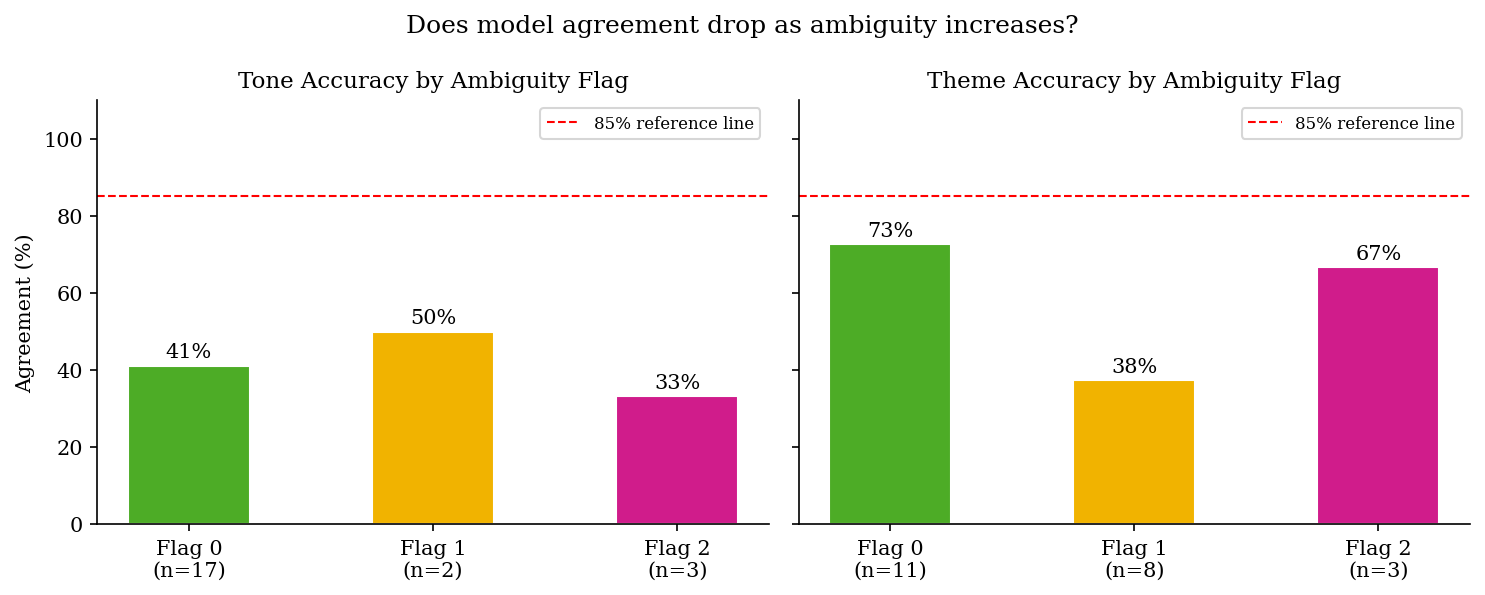

Saved: ../outputs/figures/ambiguity_flag_accuracy.png


In [6]:
# ── CELL 6: RQ2 — AMBIGUITY FLAG BREAKDOWN ───────────────────────────
# Key analytical question: does agreement DROP as ambiguity flag rises?
# Tests whether the model fails in the same places the human found hard.

g = gold.dropna(subset=['model_tone','model_theme'])

print('=== ACCURACY BY AMBIGUITY FLAG ===')
print()
print('TONE:')
for flag_val in [0, 1, 2]:
    subset = g[g['tone_flag'] == flag_val]
    if len(subset) == 0:
        print(f'  Flag {flag_val}: no choruses')
        continue
    acc = accuracy_score(subset['human_tone'], subset['model_tone'])
    correct = (subset['human_tone'] == subset['model_tone']).sum()
    choruses = subset['chorus_id'].tolist()
    print(f'  Flag {flag_val} (n={len(subset)}): {correct}/{len(subset)} correct '
          f'({acc*100:.0f}%)  — choruses: {choruses}')

print()
print('THEME:')
for flag_val in [0, 1, 2]:
    subset = g[g['theme_flag'] == flag_val]
    if len(subset) == 0:
        print(f'  Flag {flag_val}: no choruses')
        continue
    acc = accuracy_score(subset['human_theme'], subset['model_theme'])
    correct = (subset['human_theme'] == subset['model_theme']).sum()
    choruses = subset['chorus_id'].tolist()
    print(f'  Flag {flag_val} (n={len(subset)}): {correct}/{len(subset)} correct '
          f'({acc*100:.0f}%)  — choruses: {choruses}')

print()
# Bar chart: accuracy by flag level for tone and theme side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, dim, flag_col, label in [
    (axes[0], 'tone',  'tone_flag',  'Tone'),
    (axes[1], 'theme', 'theme_flag', 'Theme')
]:
    accs, ns, labels_x = [], [], []
    for fv in [0, 1, 2]:
        sub = g[g[flag_col] == fv]
        if len(sub) == 0: continue
        accs.append(accuracy_score(sub[f'human_{dim}'], sub[f'model_{dim}']))
        ns.append(len(sub))
        labels_x.append(f'Flag {fv}\n(n={len(sub)})')

    colors = ['#4dac26','#f1b300','#d01c8b'][:len(accs)]
    bars = ax.bar(labels_x, [a*100 for a in accs], color=colors,
                  edgecolor='white', width=0.5)
    ax.set_ylim(0, 110)
    ax.axhline(85, color='red', linestyle='--', lw=1,
               label='85% reference line')
    ax.set_ylabel('Agreement (%)' if ax == axes[0] else '')
    ax.set_title(f'{label} Accuracy by Ambiguity Flag', fontsize=11)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                f'{acc*100:.0f}%', ha='center', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Does model agreement drop as ambiguity increases?', fontsize=12)
plt.tight_layout()
path = FIG_DIR / 'ambiguity_flag_accuracy.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [7]:
# ── CELL 7: REST CHORUS SANITY CHECK ─────────────────────────────────
# The three rest choruses (11, 36, 138) should all be TH6.
# They are the clearest surface-signal test in the corpus.
# The 11th is also in the gold standard — check both.

rest = df[df['rest_chorus'] == True][['chorus_id','model_tone','model_theme']]
print('=== REST CHORUS CLASSIFICATIONS ===')
print(rest.to_string(index=False))
print()
th6_hits = (rest['model_theme'] == 'TH6').sum()
print(f'TH6 hit rate: {th6_hits}/3')

if th6_hits < 3:
    missed = rest[rest['model_theme'] != 'TH6']
    print(f'Missed TH6 on: {missed["chorus_id"].tolist()}')
    print('These choruses have parenthetical stage directions as TH6 surface signals.')
    print('Model assigned different theme — suggests surface signal detection failure.')
    print('Relevant to Section 6 discussion of visual features invisible to LLM.')
else:
    print('All three rest choruses correctly classified TH6.')

# Also check tone on rest choruses
print()
print('Tone assignments on rest choruses (T1 expected per Jones):')
for _, row in rest.iterrows():
    note = '← expected' if row['model_tone'] == 'T1' else '← UNEXPECTED'
    print(f'  Chorus {row["chorus_id"]}: {row["model_tone"]}  {note}')

=== REST CHORUS CLASSIFICATIONS ===
chorus_id model_tone model_theme
       11         T2         TH2
       36         T2         TH2
      138         T2         TH4

TH6 hit rate: 0/3
Missed TH6 on: ['11', '36', '138']
These choruses have parenthetical stage directions as TH6 surface signals.
Model assigned different theme — suggests surface signal detection failure.
Relevant to Section 6 discussion of visual features invisible to LLM.

Tone assignments on rest choruses (T1 expected per Jones):
  Chorus 11: T2  ← UNEXPECTED
  Chorus 36: T2  ← UNEXPECTED
  Chorus 138: T2  ← UNEXPECTED


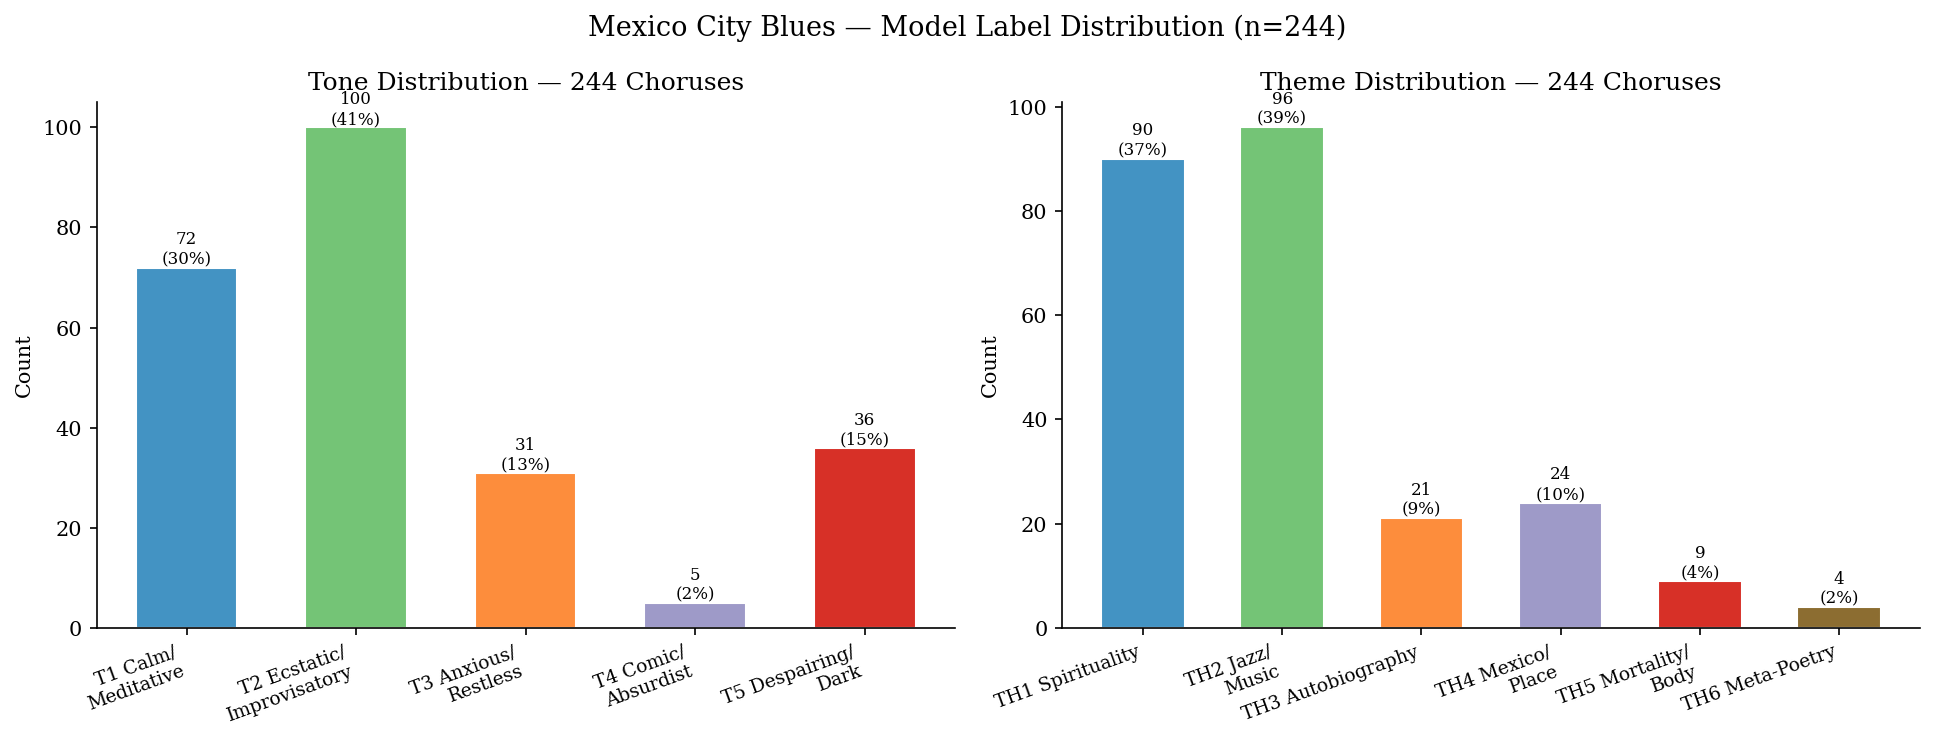

Saved: ../outputs/figures/distribution_bar.png

Tone summary:
  T1: 72 (29.5%)
  T2: 100 (41.0%)
  T3: 31 (12.7%)
  T4: 5 (2.0%)
  T5: 36 (14.8%)

Theme summary:
  TH1: 90 (36.9%)
  TH2: 96 (39.3%)
  TH3: 21 (8.6%)
  TH4: 24 (9.8%)
  TH5: 9 (3.7%)
  TH6: 4 (1.6%)


In [11]:
# ── CELL 8: RQ3 — FULL CORPUS DISTRIBUTION BAR CHARTS ────────────────
# What does the model find dominant across 244 choruses?
# Compare to what Jones's structural account would predict.
# ── CELL 8: RQ3 — FULL CORPUS DISTRIBUTION BAR CHARTS ────────────────

tone_counts  = df['model_tone'].value_counts().reindex(TONE_LABELS, fill_value=0)
theme_counts = df['model_theme'].value_counts().reindex(THEME_LABELS, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tone
bars_t = axes[0].bar(
    range(len(TONE_LABELS)),
    tone_counts.values,
    color=[TONE_COLORS[t] for t in TONE_LABELS],
    edgecolor='white', width=0.6
)
axes[0].set_title('Tone Distribution — 244 Choruses', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(len(TONE_LABELS)))
axes[0].set_xticklabels(
    [TONE_NAMES[t].replace('/', '/\n') for t in TONE_LABELS],
    rotation=20, ha='right', fontsize=9
)
for bar, val in zip(bars_t, tone_counts.values):
    pct = val / 244 * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{val}\n({pct:.0f}%)',
        ha='center', fontsize=8
    )

# Theme
bars_th = axes[1].bar(
    range(len(THEME_LABELS)),
    theme_counts.values,
    color=[THEME_COLORS[t] for t in THEME_LABELS],
    edgecolor='white', width=0.6
)
axes[1].set_title('Theme Distribution — 244 Choruses', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(THEME_LABELS)))
axes[1].set_xticklabels(
    [THEME_NAMES[t].replace('/', '/\n') for t in THEME_LABELS],
    rotation=20, ha='right', fontsize=9
)
for bar, val in zip(bars_th, theme_counts.values):
    pct = val / 244 * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f'{val}\n({pct:.0f}%)',
                 ha='center', fontsize=8)

plt.suptitle('Mexico City Blues — Model Label Distribution (n=244)', fontsize=13)
plt.tight_layout()
path = FIG_DIR / 'distribution_bar.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

print()
print('Tone summary:')
for t in TONE_LABELS:
    n = tone_counts[t]
    print(f'  {t}: {n} ({n/244*100:.1f}%)')
print()
print('Theme summary:')
for t in THEME_LABELS:
    n = theme_counts[t]
    print(f'  {t}: {n} ({n/244*100:.1f}%)')

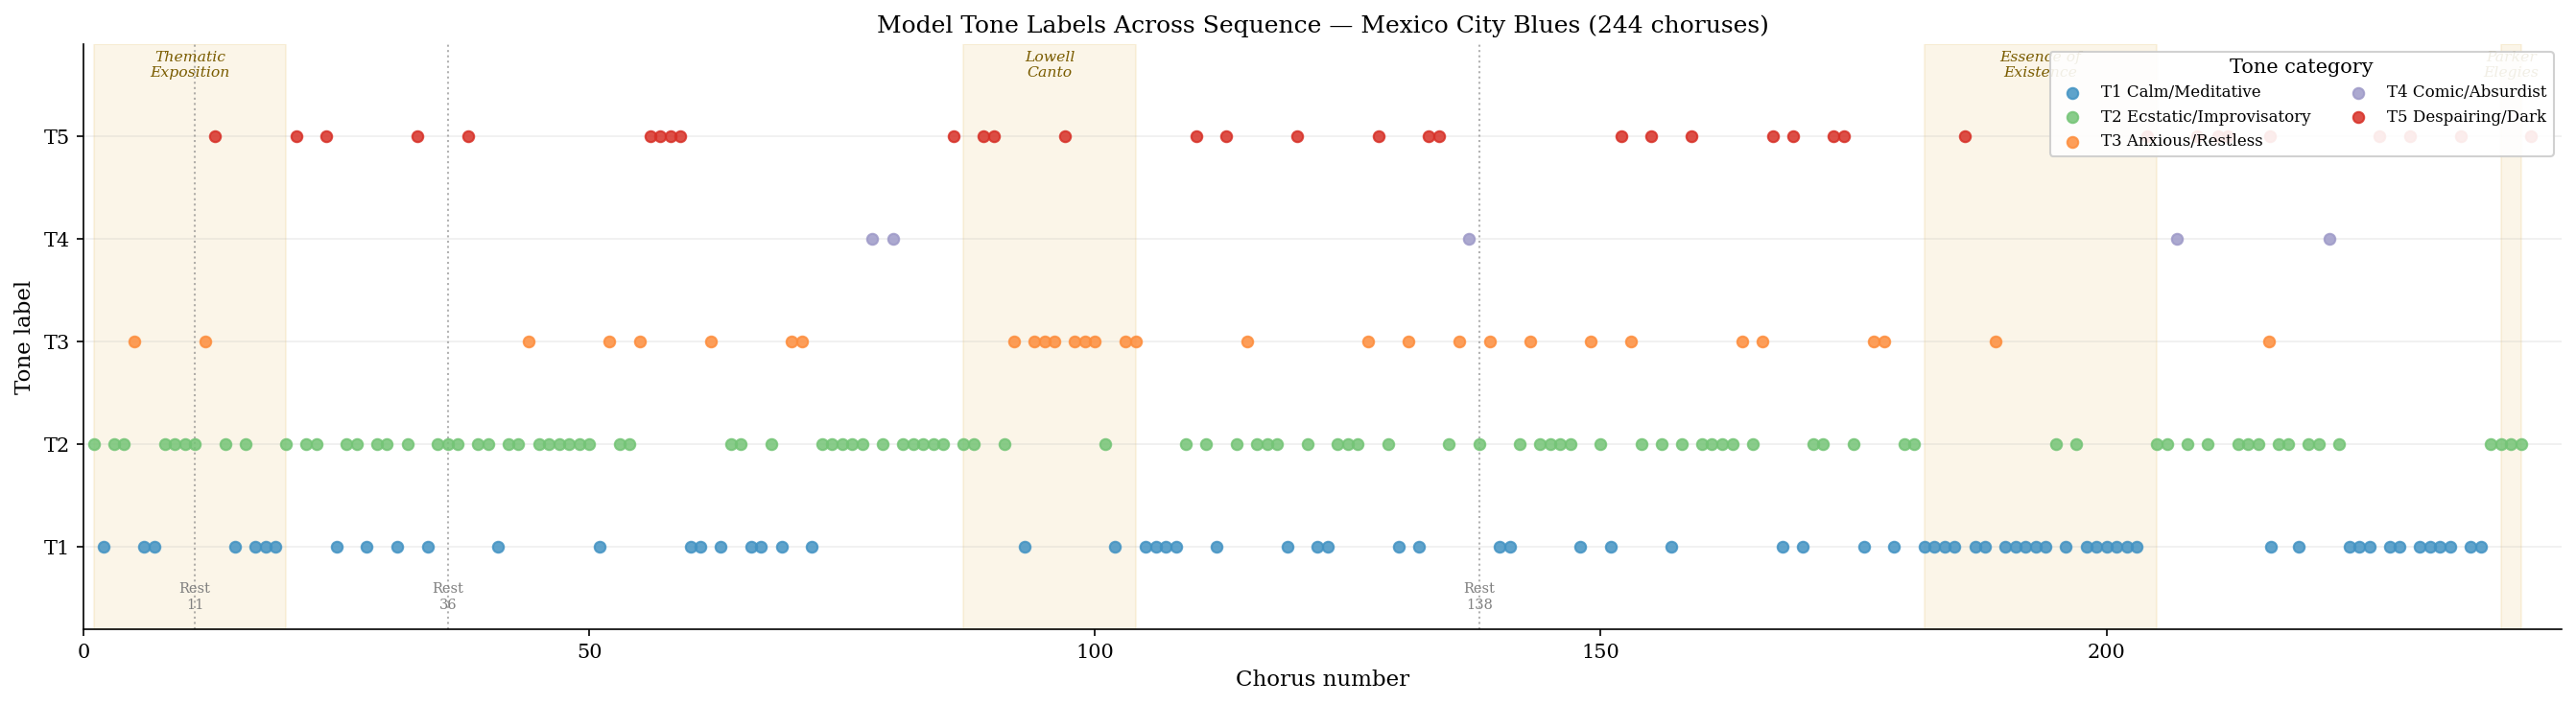

Saved: ../outputs/figures/sequence_tone.png


In [12]:
# ── CELL 9: RQ3 — SEQUENCE PLOT: TONE ACROSS THE ARC ─────────────────
# Every dot is a chorus. X = sequence position. Y = tone label.
# Gold shading marks Jones's named structural zones.
# This is the primary RQ3 visualisation — tests whether the tonal
# arc matches Jones's structural account at scale.

df_seq = df.sort_values('chorus_num').dropna(subset=['model_tone'])
tone_order = {t: i+1 for i, t in enumerate(TONE_LABELS)}
df_seq['tone_num'] = df_seq['model_tone'].map(tone_order)

fig, ax = plt.subplots(figsize=(18, 5))

# Plot each tone as a separate scatter series
for tone in TONE_LABELS:
    sub = df_seq[df_seq['model_tone'] == tone]
    ax.scatter(
        sub['chorus_num'], sub['tone_num'],
        c=TONE_COLORS[tone], label=TONE_NAMES[tone],
        s=30, alpha=0.85, zorder=3
    )

# Jones's structural zones — shaded bands
zones = [
    (1,   20,  'Thematic\nExposition',   0.10),
    (87,  104, 'Lowell\nCanto',          0.10),
    (182, 205, 'Essence of\nExistence',  0.10),
    (239, 241, 'Parker\nElegies',        0.10),
]
for start, end, name, alpha in zones:
    ax.axvspan(start, end, alpha=alpha, color='goldenrod', zorder=1)
    ax.text((start+end)/2, 5.55, name,
            ha='center', va='bottom', fontsize=7.5,
            color='#7a5c00', style='italic')

# Mark rest choruses
for rc_id, rc_num in [('11', 11), ('36', 36), ('138', 138)]:
    ax.axvline(rc_num, color='gray', linestyle=':', lw=1, alpha=0.6)
    ax.text(rc_num, 0.4, f'Rest\n{rc_id}',
            ha='center', fontsize=7, color='gray')

ax.set_yticks(list(tone_order.values()))
ax.set_yticklabels(TONE_LABELS, fontsize=10)
ax.set_xlabel('Chorus number', fontsize=11)
ax.set_ylabel('Tone label', fontsize=11)
ax.set_title(
    'Model Tone Labels Across Sequence — Mexico City Blues (244 choruses)',
    fontsize=12
)
ax.set_ylim(0.2, 5.9)
ax.set_xlim(0, 245)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9,
          ncol=2, title='Tone category')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
path = FIG_DIR / 'sequence_tone.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

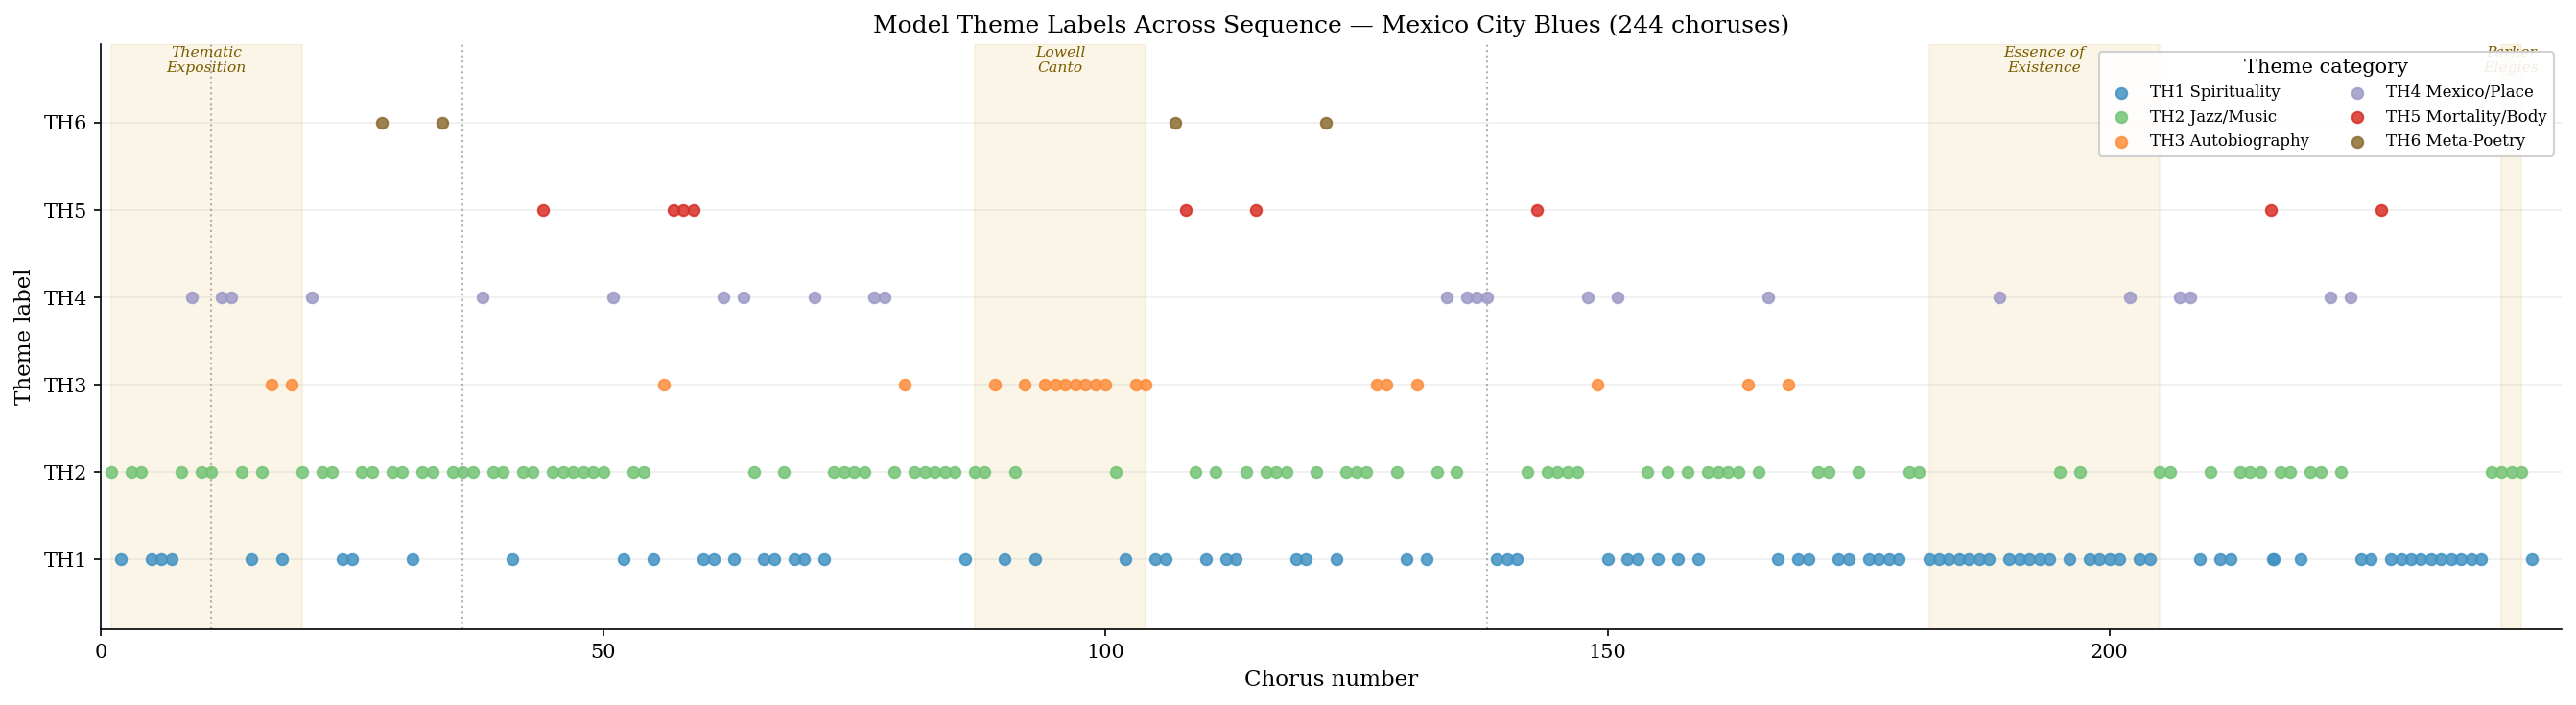

Saved: ../outputs/figures/sequence_theme.png


In [13]:
# ── CELL 10: RQ3 — SEQUENCE PLOT: THEME ACROSS THE ARC ───────────────
# Same as cell 9 but for theme labels.

theme_order = {t: i+1 for i, t in enumerate(THEME_LABELS)}
df_seq['theme_num'] = df_seq['model_theme'].map(theme_order)

fig, ax = plt.subplots(figsize=(18, 5))

for theme in THEME_LABELS:
    sub = df_seq[df_seq['model_theme'] == theme]
    ax.scatter(
        sub['chorus_num'], sub['theme_num'],
        c=THEME_COLORS[theme], label=THEME_NAMES[theme],
        s=30, alpha=0.85, zorder=3
    )

zones = [
    (1,   20,  'Thematic\nExposition',  0.10),
    (87,  104, 'Lowell\nCanto',         0.10),
    (182, 205, 'Essence of\nExistence', 0.10),
    (239, 241, 'Parker\nElegies',       0.10),
]
for start, end, name, alpha in zones:
    ax.axvspan(start, end, alpha=alpha, color='goldenrod', zorder=1)
    ax.text((start+end)/2, 6.55, name,
            ha='center', va='bottom', fontsize=7.5,
            color='#7a5c00', style='italic')

for rc_num in [11, 36, 138]:
    ax.axvline(rc_num, color='gray', linestyle=':', lw=1, alpha=0.6)

ax.set_yticks(list(theme_order.values()))
ax.set_yticklabels(THEME_LABELS, fontsize=10)
ax.set_xlabel('Chorus number', fontsize=11)
ax.set_ylabel('Theme label', fontsize=11)
ax.set_title(
    'Model Theme Labels Across Sequence — Mexico City Blues (244 choruses)',
    fontsize=12
)
ax.set_ylim(0.2, 6.9)
ax.set_xlim(0, 245)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9,
          ncol=2, title='Theme category')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
path = FIG_DIR / 'sequence_theme.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

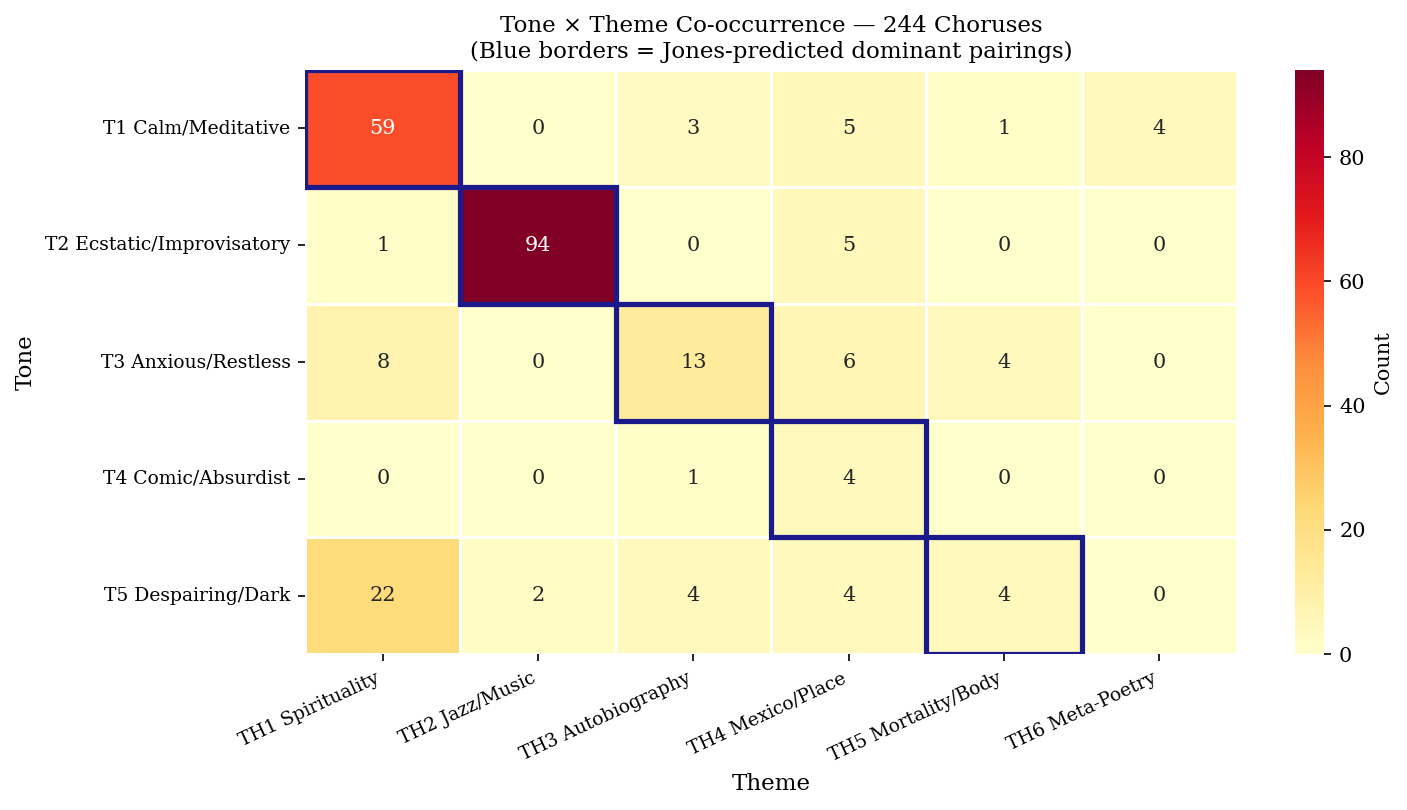

Saved: ../outputs/figures/crosstab_tone_theme.png

Cross-tabulation:
Theme  TH1  TH2  TH3  TH4  TH5  TH6
Tone                               
T1      59    0    3    5    1    4
T2       1   94    0    5    0    0
T3       8    0   13    6    4    0
T4       0    0    1    4    0    0
T5      22    2    4    4    4    0


In [14]:
# ── CELL 11: RQ3 — TONE × THEME CROSS-TABULATION ─────────────────────
# Which tone-theme combinations does the model find?
# Jones predicts: T1↔TH1, T2↔TH2, T5↔TH5.
# Unexpected co-occurrences are the most analytically interesting cells.

crosstab = pd.crosstab(
    df['model_tone'], df['model_theme'],
    rownames=['Tone'], colnames=['Theme']
).reindex(index=TONE_LABELS, columns=THEME_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    crosstab, annot=True, fmt='d',
    cmap='YlOrRd', ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Count'}
)

# Highlight Jones-predicted dominant pairings
predicted_pairs = [('T1','TH1'),('T2','TH2'),('T3','TH3'),
                   ('T4','TH4'),('T5','TH5')]
for tone, theme in predicted_pairs:
    ti = TONE_LABELS.index(tone)
    thi = THEME_LABELS.index(theme)
    ax.add_patch(plt.Rectangle((thi, ti), 1, 1,
                 fill=False, edgecolor='#1a1a8c', lw=2.5))

ax.set_xlabel('Theme', fontsize=11)
ax.set_ylabel('Tone', fontsize=11)
ax.set_title(
    'Tone × Theme Co-occurrence — 244 Choruses\n'
    '(Blue borders = Jones-predicted dominant pairings)',
    fontsize=11
)
ax.set_xticklabels([THEME_NAMES[t] for t in THEME_LABELS],
                   rotation=25, ha='right', fontsize=9)
ax.set_yticklabels([TONE_NAMES[t] for t in TONE_LABELS],
                   rotation=0, fontsize=9)

plt.tight_layout()
path = FIG_DIR / 'crosstab_tone_theme.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

print()
print('Cross-tabulation:')
print(crosstab.to_string())

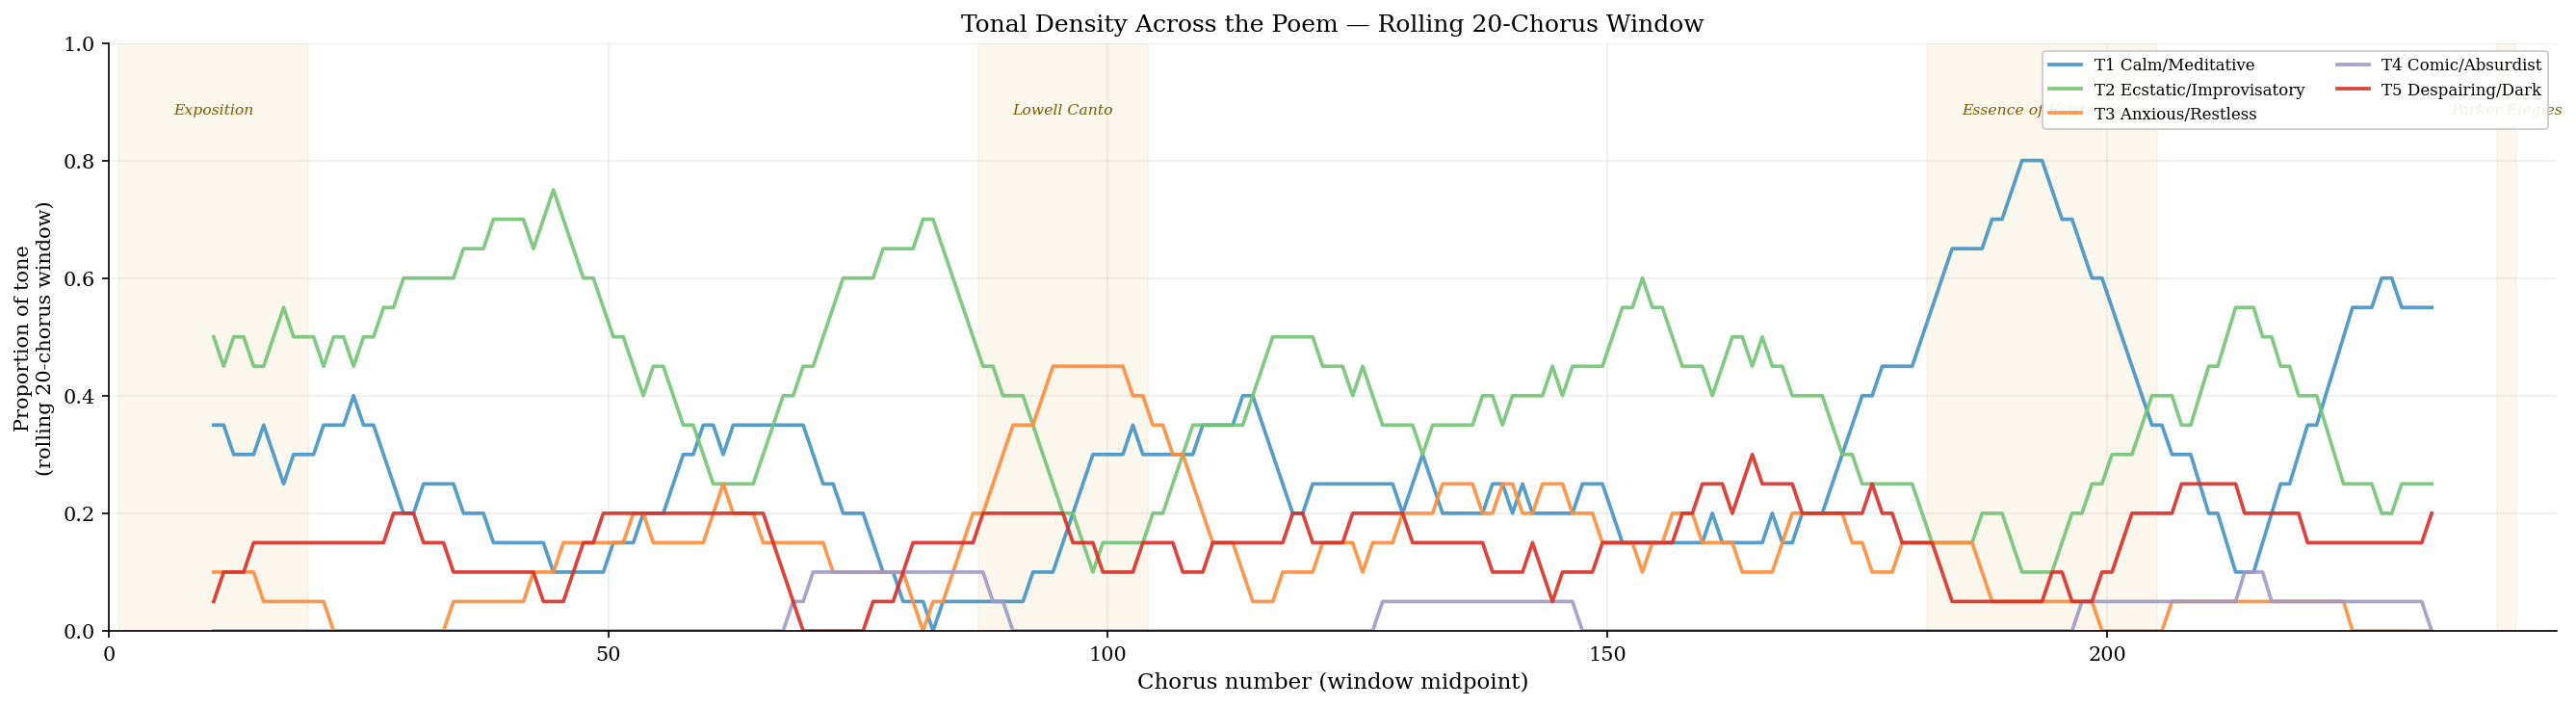

Saved: ../outputs/figures/rolling_tone.png


In [15]:
# ── CELL 12: RQ3 — ROLLING WINDOW: TONAL DENSITY ACROSS ARC ──────────
# Shows proportion of each tone in a sliding 20-chorus window.
# Reveals tonal shifts across the poem more clearly than the scatter.
# Directly testable against Jones's arc: T3/T5 should peak in
# Lowell Canto (87-104), T1 should rise in Essence of Existence.

df_seq = df.sort_values('chorus_num').reset_index(drop=True)
window = 20

# Build rolling proportions
rows = []
for i in range(len(df_seq) - window + 1):
    chunk = df_seq.iloc[i:i+window]
    mid_chorus = chunk['chorus_num'].mean()
    for tone in TONE_LABELS:
        prop = (chunk['model_tone'] == tone).sum() / window
        rows.append({'chorus_mid': mid_chorus, 'tone': tone, 'proportion': prop})

roll = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(18, 5))

for tone in TONE_LABELS:
    sub = roll[roll['tone'] == tone]
    ax.plot(
        sub['chorus_mid'], sub['proportion'],
        color=TONE_COLORS[tone], lw=1.8,
        label=TONE_NAMES[tone], alpha=0.9
    )

# Structural zones
zones = [
    (1,   20,  'Exposition'),
    (87,  104, 'Lowell Canto'),
    (182, 205, 'Essence of Existence'),
    (239, 241, 'Parker Elegies'),
]
for start, end, name in zones:
    ax.axvspan(start, end, alpha=0.08, color='goldenrod')
    ax.text((start+end)/2, 0.88, name,
            ha='center', fontsize=7.5, color='#7a5c00', style='italic')

ax.set_xlabel('Chorus number (window midpoint)', fontsize=11)
ax.set_ylabel(f'Proportion of tone\n(rolling {window}-chorus window)', fontsize=10)
ax.set_title(
    f'Tonal Density Across the Poem — Rolling {window}-Chorus Window',
    fontsize=12
)
ax.set_xlim(0, 245)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
ax.grid(alpha=0.2)

plt.tight_layout()
path = FIG_DIR / 'rolling_tone.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [16]:
# ── CELL 13: SECTION 5 SUMMARY PRINTOUT ──────────────────────────────
# All numbers needed for writing Section 5 in one place.

g = gold.dropna(subset=['model_tone','model_theme'])

tone_acc    = accuracy_score(g['human_tone'],  g['model_tone'])
theme_acc   = accuracy_score(g['human_theme'], g['model_theme'])
tone_kappa  = cohen_kappa_score(g['human_tone'],  g['model_tone'])
theme_kappa = cohen_kappa_score(g['human_theme'], g['model_theme'])

tone_disagree  = g[g['human_tone']  != g['model_tone']]
theme_disagree = g[g['human_theme'] != g['model_theme']]

tone_counts  = df['model_tone'].value_counts().reindex(TONE_LABELS, fill_value=0)
theme_counts = df['model_theme'].value_counts().reindex(THEME_LABELS, fill_value=0)

print('=' * 60)
print('SECTION 5 NUMBERS — paste into report')
print('=' * 60)
print()
print('── RQ1 ──')
print(f'  Tone  accuracy: {tone_acc*100:.1f}%  ({int(tone_acc*22)}/22)')
print(f'  Theme accuracy: {theme_acc*100:.1f}%  ({int(theme_acc*22)}/22)')
print(f'  Tone  kappa:    {tone_kappa:.3f}  ({kappa_label(tone_kappa)})')
print(f'  Theme kappa:    {theme_kappa:.3f}  ({kappa_label(theme_kappa)})')
print()
print('── RQ2 ──')
print(f'  Tone  disagreements: {len(tone_disagree)}/22')
print(f'  Theme disagreements: {len(theme_disagree)}/22')

# Flag breakdown
for dim, flag_col in [('tone','tone_flag'),('theme','theme_flag')]:
    for fv in [0,1,2]:
        sub = g[g[flag_col]==fv]
        if len(sub)==0: continue
        acc = accuracy_score(sub[f'human_{dim}'], sub[f'model_{dim}'])
        print(f'  {dim.capitalize()} flag {fv} (n={len(sub)}): {acc*100:.0f}% agreement')

print()
print('── RQ3 ──')
print('  Tone distribution (244 choruses):')
for t in TONE_LABELS:
    print(f'    {t}: {tone_counts[t]} ({tone_counts[t]/244*100:.1f}%)')
print('  Theme distribution (244 choruses):')
for t in THEME_LABELS:
    print(f'    {t}: {theme_counts[t]} ({theme_counts[t]/244*100:.1f}%)')
print()
print('── Rest chorus check ──')
rest = df[df['rest_chorus']==True][['chorus_id','model_tone','model_theme']]
print(rest.to_string(index=False))
print(f'  TH6 hit rate: {(rest["model_theme"]=="TH6").sum()}/3')
print()
print('All figures saved to:', FIG_DIR)

SECTION 5 NUMBERS — paste into report

── RQ1 ──
  Tone  accuracy: 40.9%  (9/22)
  Theme accuracy: 59.1%  (13/22)
  Tone  kappa:    0.261  (Fair)
  Theme kappa:    0.506  (Moderate)

── RQ2 ──
  Tone  disagreements: 13/22
  Theme disagreements: 9/22
  Tone flag 0 (n=17): 41% agreement
  Tone flag 1 (n=2): 50% agreement
  Tone flag 2 (n=3): 33% agreement
  Theme flag 0 (n=11): 73% agreement
  Theme flag 1 (n=8): 38% agreement
  Theme flag 2 (n=3): 67% agreement

── RQ3 ──
  Tone distribution (244 choruses):
    T1: 72 (29.5%)
    T2: 100 (41.0%)
    T3: 31 (12.7%)
    T4: 5 (2.0%)
    T5: 36 (14.8%)
  Theme distribution (244 choruses):
    TH1: 90 (36.9%)
    TH2: 96 (39.3%)
    TH3: 21 (8.6%)
    TH4: 24 (9.8%)
    TH5: 9 (3.7%)
    TH6: 4 (1.6%)

── Rest chorus check ──
chorus_id model_tone model_theme
       11         T2         TH2
       36         T2         TH2
      138         T2         TH4
  TH6 hit rate: 0/3

All figures saved to: ../outputs/figures
